# Preprocessing & EDA — PSA Machine Translation Dataset

**Instructions:** This notebook works on either dataset. Set `INPUT_FILE` and
`TARGET_LANG` in the cell below, run the whole notebook, then change those two
values and run again for the other language.

- Run 1: `psa_dataset_dholuo_somali.csv`, target = `Dholuo`
- Run 2: `psa_dataset_ekegusii.csv`, target = `Ekegusii`

This preprocessing pipeline is intentionally thorough — every stage is logged
in a **funnel table** at the end so nothing gets silently dropped without a
record of why.


In [4]:
# ============ CONFIG — change these two lines between runs ============
INPUT_FILE = "../data/processed/psa_dataset_dholuo_somali.csv"
TARGET_LANG = "Dholuo"
# ========================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
from sklearn.model_selection import train_test_split

BASENAME = os.path.splitext(os.path.basename(INPUT_FILE))[0]
FLAGGED_DIR = f"data/interim/flagged_{TARGET_LANG.lower()}"
os.makedirs(FLAGGED_DIR, exist_ok=True)

print(f"Working on: {INPUT_FILE}")
print(f"Target language: {TARGET_LANG}")

# funnel tracks row count after each stage, for the final summary table
funnel = []
def log_stage(name, df):
    funnel.append({"Stage": name, "Rows remaining": len(df)})
    return df

Working on: ../data/processed/psa_dataset_dholuo_somali.csv
Target language: Dholuo


## 1. Load the data

In [5]:
df = pd.read_csv(INPUT_FILE)
df = log_stage("0. Raw input", df)
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
df.head()

Loaded 16029 rows, 8 columns


,PSA_Id,Domain,English,Kiswahili,Dholuo,Somali,Class,Source
0,1,Education,Comprehensive COVID-19 health and safety proto...,Itifaki kamili za afya na usalama za COVID-19 ...,Chenro mag thieth: Chenro mag thieth kod ritru...,Barnaamijyada caafimaadka iyo amniga ee COVID-...,PSA,original_baseline_dataset
1,2,Education,Digital learning platform providing free educa...,Jukwaa la kujifunza kidijitali linalotoa maudh...,Kenya Education Cloud: Ohinga mar somo mar dij...,Barashada dhijitaalka ah ee bixisa waxyaabaha ...,PSA,original_baseline_dataset
2,3,Education,KUCCPS portal will open in March 2025 for univ...,Lango la KUCCPS litafunguliwa Machi 2025 kwa n...,KUCCPS Portal: KUCCPS portal biro yawore e dwe...,Gudaha KUCCPS waxaa la furi doonaa bishii Maar...,PSA,original_baseline_dataset
3,4,Education,Target to increase school feeding beneficiarie...,Lengo ni kuongeza wanufaika wa chakula shuleni...,Medo kwan mar pidho nyithindo e skunde: Dwaro ...,Ujeedada ah in la kordhiyo dadka ka faa'iideys...,PSA,original_baseline_dataset
4,5,Education,Launch of inclusive education programs with as...,Uzinduzi wa programu za elimu jumuishi zenye t...,Somo mar Dwaro Manyien: Chako chenro mag somo ...,Bilaabista barnaamijyo waxbarasho oo dhanka ah...,PSA,original_baseline_dataset


## 2. Exploratory Data Analysis (before cleaning)

Look at the data as-is first, so we can see what cleaning actually needs to fix.

### 2.1 Domain distribution

Domain
Health               3764
Agriculture          3645
Education            2844
Governance           2748
Security             1795
Security & Safety    1233
Name: count, dtype: int64


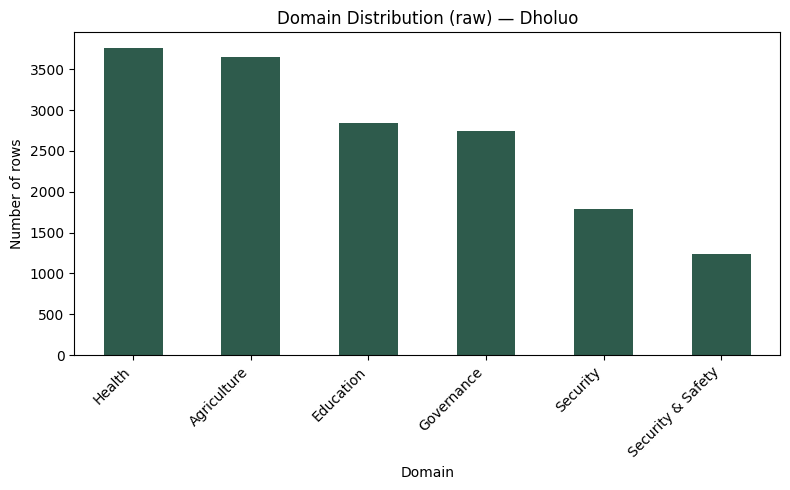

In [6]:
domain_counts = df["Domain"].value_counts()
print(domain_counts)

plt.figure(figsize=(8, 5))
domain_counts.plot(kind="bar", color="#2E5B4C")
plt.title(f"Domain Distribution (raw) — {TARGET_LANG}")
plt.ylabel("Number of rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 2.2 Source distribution

Source
grounded_generated           10917
original_baseline_dataset     5112
Name: count, dtype: int64


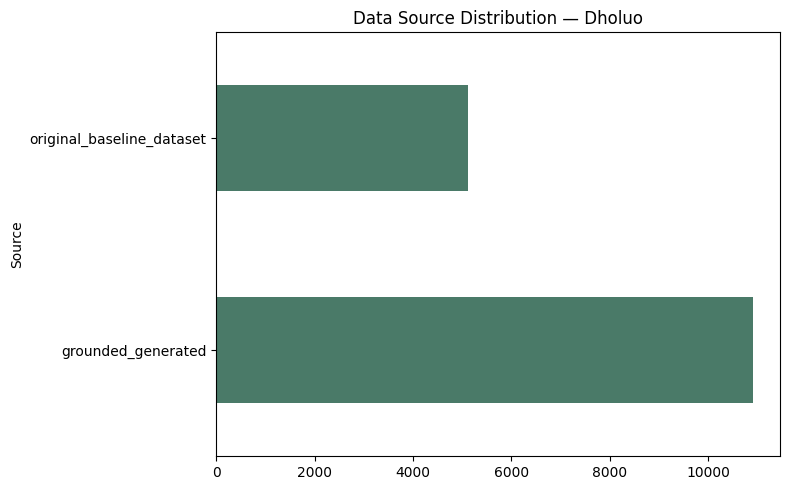

In [7]:
if "Source" in df.columns:
    source_counts = df["Source"].value_counts()
    print(source_counts)
    plt.figure(figsize=(8, 5))
    source_counts.plot(kind="barh", color="#4A7A68")
    plt.title(f"Data Source Distribution — {TARGET_LANG}")
    plt.tight_layout()
    plt.show()
else:
    print("No Source column in this file.")

### 2.3 Sentence length distribution (all languages)

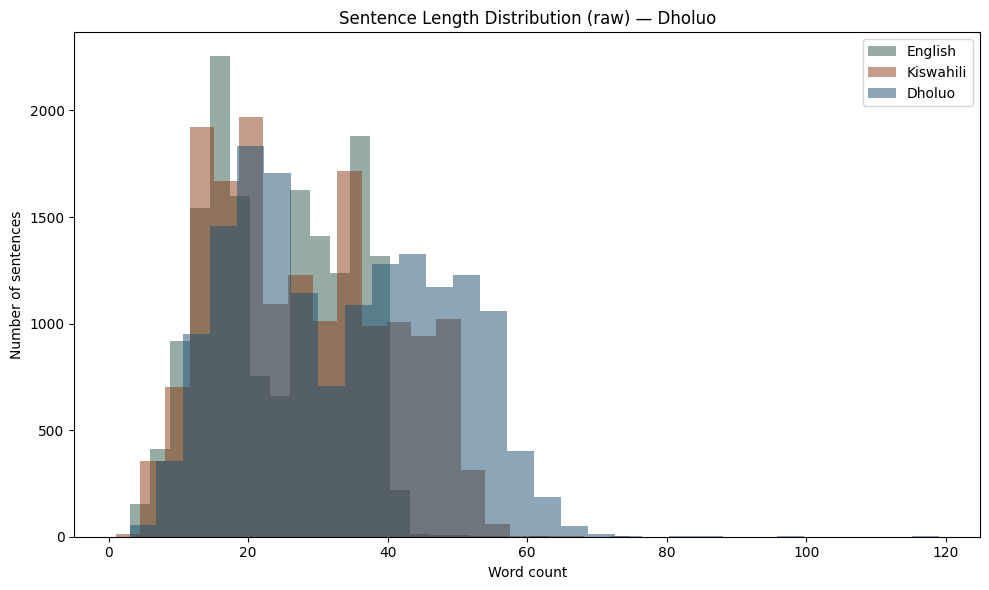

In [8]:
plt.figure(figsize=(10, 6))
for col, color in [("English", "#2E5B4C"), ("Kiswahili", "#8A3B12"), (TARGET_LANG, "#1B4F72")]:
    wc = df[col].dropna().str.split().apply(len)
    plt.hist(wc, bins=30, alpha=0.5, label=col, color=color)
plt.legend()
plt.xlabel("Word count")
plt.ylabel("Number of sentences")
plt.title(f"Sentence Length Distribution (raw) — {TARGET_LANG}")
plt.tight_layout()
plt.show()

## 3. Preprocessing — Stage A: Structural completeness

Drop rows missing any of the three required text fields outright — nothing
downstream can be checked on a row with no text.

In [9]:
required = ["English", "Kiswahili", TARGET_LANG]
df = df.dropna(subset=required).reset_index(drop=True)
df = log_stage("A. Drop missing required fields", df)
print(f"Rows remaining: {len(df)}")

Rows remaining: 16029


## 4. Preprocessing — Stage B: Text normalization

- Collapse whitespace/newlines
- Strip invisible Unicode characters (zero-width spaces, direction marks)
- Normalize smart quotes to straight quotes
- Strip leftover HTML tags and raw URLs (scraping artifacts)


In [10]:
def normalize_text(text):
    if not isinstance(text, str):
        return text
    text = text.strip()
    text = re.sub(r"<[^>]+>", " ", text)                    # HTML tags
    text = re.sub(r"https?://\S+", " ", text)                # URLs
    text = re.sub(r"\s+", " ", text)                          # collapse whitespace
    text = re.sub(r"[\u200b\u200e\u200f]", "", text)          # invisible chars
    text = text.replace("\u2018", "'").replace("\u2019", "'")
    text = text.replace("\u201c", '"').replace("\u201d", '"')
    return text.strip()

for col in ["English", "Kiswahili", TARGET_LANG]:
    df[col] = df[col].apply(normalize_text)

# drop anything that went empty after stripping tags/URLs
for col in ["English", "Kiswahili", TARGET_LANG]:
    df = df[df[col].str.len() > 0]
df = df.reset_index(drop=True)
df = log_stage("B. Text normalization", df)
print(f"Rows remaining: {len(df)}")

Rows remaining: 16029


In [11]:
df.head(5)

,PSA_Id,Domain,English,Kiswahili,Dholuo,Somali,Class,Source
0,1,Education,Comprehensive COVID-19 health and safety proto...,Itifaki kamili za afya na usalama za COVID-19 ...,Chenro mag thieth: Chenro mag thieth kod ritru...,Barnaamijyada caafimaadka iyo amniga ee COVID-...,PSA,original_baseline_dataset
1,2,Education,Digital learning platform providing free educa...,Jukwaa la kujifunza kidijitali linalotoa maudh...,Kenya Education Cloud: Ohinga mar somo mar dij...,Barashada dhijitaalka ah ee bixisa waxyaabaha ...,PSA,original_baseline_dataset
2,3,Education,KUCCPS portal will open in March 2025 for univ...,Lango la KUCCPS litafunguliwa Machi 2025 kwa n...,KUCCPS Portal: KUCCPS portal biro yawore e dwe...,Gudaha KUCCPS waxaa la furi doonaa bishii Maar...,PSA,original_baseline_dataset
3,4,Education,Target to increase school feeding beneficiarie...,Lengo ni kuongeza wanufaika wa chakula shuleni...,Medo kwan mar pidho nyithindo e skunde: Dwaro ...,Ujeedada ah in la kordhiyo dadka ka faa'iideys...,PSA,original_baseline_dataset
4,5,Education,Launch of inclusive education programs with as...,Uzinduzi wa programu za elimu jumuishi zenye t...,Somo mar Dwaro Manyien: Chako chenro mag somo ...,Bilaabista barnaamijyo waxbarasho oo dhanka ah...,PSA,original_baseline_dataset


## 5. Preprocessing — Stage C: Garbage / junk detection

Catches things length-filtering alone would miss:
- **Repeated consecutive words** (e.g. "the the", or the "understanding understanding"
  bug found earlier in this project)
- **Leftover template placeholders** (e.g. a stray `{fact}` that didn't get filled)
- **Punctuation-only or digit-only rows**
- **Extremely low character diversity** (e.g. "aaaaaaaaaa" — a common scraping/OCR artifact)

Flagged rows are saved for manual review rather than silently deleted, in case
of false positives.


In [ ]:
def has_repeated_word(text):
    return bool(re.search(r"\b(\w+)\s+\1\b", text, flags=re.IGNORECASE))

def has_leftover_placeholder(text):
    return bool(re.search(r"\{[a-zA-Z_0-9]+\}", text))

def is_punct_or_digit_only(text):
    stripped = re.sub(r"[\s\W\d]", "", text)
    return len(stripped) == 0

def low_char_diversity(text, threshold=0.15):
    letters = re.sub(r"\s", "", text.lower())
    if len(letters) < 5:
        return False
    return (len(set(letters)) / len(letters)) < threshold

junk_mask = pd.Series(False, index=df.index)
junk_reasons = pd.Series("", index=df.index)

for col in ["English", "Kiswahili", TARGET_LANG]:
    rep = df[col].apply(has_repeated_word)
    ph = df[col].apply(has_leftover_placeholder)
    pd_only = df[col].apply(is_punct_or_digit_only)
    low_div = df[col].apply(low_char_diversity)

    junk_mask |= rep | ph | pd_only | low_div
    junk_reasons = junk_reasons.mask(rep, junk_reasons + f"{col}:repeated_word; ")
    junk_reasons = junk_reasons.mask(ph, junk_reasons + f"{col}:leftover_placeholder; ")
    junk_reasons = junk_reasons.mask(pd_only, junk_reasons + f"{col}:punct_or_digit_only; ")
    junk_reasons = junk_reasons.mask(low_div, junk_reasons + f"{col}:low_char_diversity; ")

flagged_junk = df[junk_mask].copy()
flagged_junk["flag_reason"] = junk_reasons[junk_mask]
flagged_junk.to_csv(f"{FLAGGED_DIR}/flagged_junk.csv", index=False)

print(f"Flagged {junk_mask.sum()} rows as junk -> {FLAGGED_DIR}/flagged_junk.csv")
df = df[~junk_mask].reset_index(drop=True)
df = log_stage("C. Garbage/junk detection", df)
print(f"Rows remaining: {len(df)}")

## 6. Preprocessing — Stage D: Length filtering + cross-language length ratio

Beyond simple word-count bounds, check that the **ratio** between English
length and target-language length is plausible — if English is 5 words but
the translation is 60 words (or vice versa), that's a strong signal of a
truncated, merged, or mistranslated row, even if each individual length
looks fine on its own.


In [ ]:
df["eng_word_count"] = df["English"].str.split().apply(len)
df["target_word_count"] = df[TARGET_LANG].str.split().apply(len)

# absolute bounds
before = len(df)
df = df[(df["eng_word_count"] >= 3) & (df["eng_word_count"] <= 60)]
print(f"Dropped {before - len(df)} rows outside 3-60 word range (English)")

# ratio check — flag (don't auto-drop) rows where target is >4x or <0.25x English length
df["length_ratio"] = df["target_word_count"] / df["eng_word_count"]
ratio_outliers = df[(df["length_ratio"] > 4) | (df["length_ratio"] < 0.25)]
ratio_outliers.to_csv(f"{FLAGGED_DIR}/flagged_length_ratio_outliers.csv", index=False)
print(f"Flagged {len(ratio_outliers)} rows with suspicious length ratios -> {FLAGGED_DIR}/flagged_length_ratio_outliers.csv")

# drop the most extreme ratio outliers (likely broken rows), keep borderline ones for manual review
before = len(df)
df = df[(df["length_ratio"] <= 8) & (df["length_ratio"] >= 0.1)].reset_index(drop=True)
print(f"Dropped {before - len(df)} extreme length-ratio outliers (ratio > 8x or < 0.1x)")

df = df.drop(columns=["eng_word_count", "target_word_count", "length_ratio"])
df = log_stage("D. Length + length-ratio filtering", df)
print(f"Rows remaining: {len(df)}")

## 7. Preprocessing — Stage E: Duplicate detection (exact + near-duplicate)

Exact duplicates are easy. Near-duplicates (same sentence with a trailing
period, extra space, or capitalization difference) slip past exact matching —
catch those by comparing a normalized version of each sentence.


In [ ]:
before = len(df)
df = df.drop_duplicates(subset="English").reset_index(drop=True)
print(f"Dropped {before - len(df)} exact duplicate rows")

def normalize_for_dedup(text):
    text = text.lower().strip()
    text = re.sub(r"[^\w\s]", "", text)   # strip punctuation
    text = re.sub(r"\s+", " ", text)
    return text

df["_dedup_key"] = df["English"].apply(normalize_for_dedup)
before = len(df)
near_dupes = df[df.duplicated(subset="_dedup_key", keep=False)].sort_values("_dedup_key")
near_dupes.to_csv(f"{FLAGGED_DIR}/flagged_near_duplicates.csv", index=False)
print(f"Found {len(near_dupes)} rows involved in near-duplicate groups -> {FLAGGED_DIR}/flagged_near_duplicates.csv")

df = df.drop_duplicates(subset="_dedup_key", keep="first").reset_index(drop=True)
df = df.drop(columns=["_dedup_key"])
print(f"Dropped {before - len(df)} near-duplicate rows (kept first occurrence in each group)")
df = log_stage("E. Duplicate + near-duplicate removal", df)
print(f"Rows remaining: {len(df)}")

## 8. Preprocessing — Stage F: Domain & label validation

Ensure every row's `Domain` is one of the 5 expected values — anything else
(a typo, a stray category) gets flagged rather than silently kept or dropped.


In [ ]:
df["Domain"] = df["Domain"].replace({"Security & Safety": "Security"})

VALID_DOMAINS = {"Health", "Agriculture", "Education", "Security", "Governance"}
invalid_domain_mask = ~df["Domain"].isin(VALID_DOMAINS)
invalid_domains = df[invalid_domain_mask]
if len(invalid_domains):
    invalid_domains.to_csv(f"{FLAGGED_DIR}/flagged_invalid_domains.csv", index=False)
    print(f"Flagged {len(invalid_domains)} rows with unexpected Domain values -> {FLAGGED_DIR}/flagged_invalid_domains.csv")
    print(df[invalid_domain_mask]["Domain"].value_counts())
else:
    print("All Domain values are valid.")

df = df[~invalid_domain_mask].reset_index(drop=True)
df = log_stage("F. Domain validation", df)
print(f"Rows remaining: {len(df)}")

## 9. Preprocessing — Stage G: Language-ID validation (English & Kiswahili)

Neither Dholuo nor Ekegusii is supported by langdetect, so this only checks
the two languages it *can* validate. Flags rather than drops — short
sentences commonly produce false positives.


In [ ]:
from langdetect import detect, DetectorFactory, LangDetectException
DetectorFactory.seed = 42

def safe_detect(text):
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

df["English_detected"] = df["English"].apply(safe_detect)
df["Kiswahili_detected"] = df["Kiswahili"].apply(safe_detect)

lang_mismatch = df[(df["English_detected"] != "en") | (df["Kiswahili_detected"] != "sw")]
lang_mismatch.to_csv(f"{FLAGGED_DIR}/flagged_language_mismatch.csv", index=False)
print(f"Flagged {len(lang_mismatch)} rows ({len(lang_mismatch)/len(df)*100:.1f}%) with language-ID mismatches -> {FLAGGED_DIR}/flagged_language_mismatch.csv")
print("These are NOT auto-dropped — review the flagged file, since short sentences")
print("often trigger false positives in langdetect.")

df = df.drop(columns=["English_detected", "Kiswahili_detected"])

### Save the cleaned dataset

In [ ]:
df["PSA_Id"] = range(1, len(df) + 1)
CLEANED_FILE = f"../data/processed/{BASENAME}_preprocessed.csv"
df.to_csv(CLEANED_FILE, index=False)
print(f"Saved: {CLEANED_FILE} ({len(df)} rows)")

## 10. The Funnel Table — what got caught at each stage

This is the core record of "did we catch everything" — every stage's row
count is logged here, so the total drop and the reason for each drop is
fully traceable.


In [ ]:
funnel_df = pd.DataFrame(funnel)
funnel_df["Rows dropped this stage"] = -funnel_df["Rows remaining"].diff().fillna(0).astype(int)
print(funnel_df.to_string(index=False))

funnel_df.to_csv(f"../reports/eda_{TARGET_LANG.lower()}_funnel.csv", index=False)

plt.figure(figsize=(10, 5))
plt.plot(funnel_df["Stage"], funnel_df["Rows remaining"], marker="o", color="#2E5B4C")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Rows remaining")
plt.title(f"Preprocessing Funnel — {TARGET_LANG}")
plt.tight_layout()
plt.show()

## 11. Train / Validation / Test Split

80/10/10, stratified by domain.

In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["Domain"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["Domain"])

train_df.to_csv(f"../data/processed/{BASENAME}_train.csv", index=False)
val_df.to_csv(f"../data/processed/{BASENAME}_val.csv", index=False)
test_df.to_csv(f"../data/processed/{BASENAME}_test.csv", index=False)

print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")

## 12. Post-cleaning EDA (sanity check)

In [ ]:
plt.figure(figsize=(8, 5))
df["Domain"].value_counts().plot(kind="bar", color="#2E5B4C")
plt.title(f"Domain Distribution After Cleaning — {TARGET_LANG}")
plt.ylabel("Number of rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

def vocab_size(series):
    words = set()
    for s in series.dropna():
        words.update(s.lower().split())
    return len(words)

for col in ["English", "Kiswahili", TARGET_LANG]:
    print(f"{col}: ~{vocab_size(df[col])} unique tokens")

## Summary

Fill this in after reviewing the funnel table and flagged files:

- Total rows after cleaning: 
- Total rows dropped, and the single biggest cause: 
- Rows flagged for manual review (junk / length-ratio / near-dup / language / domain) — has someone reviewed these yet?
- Domain balance notes: 
- Anything that still needs a second pass: 
